# Técnica Especial — Extração de Dados de Faturas em PDF

**Disciplina:** Machine Learning — Técnicas Especiais de Análise de Dados
**Aluno:** Eduardo Vitor Oliveira
**Professor:** Ricardo
**Data:** 18/09/2026
**Dataset:** [High-Quality OCR-Ready Invoice PDFs](https://www.kaggle.com/datasets/devp1866/high-quality-ocr-ready-invoice-pdfs) — Kaggle (100 faturas em PDF, prontas para leitura de texto e tabela)

### Objetivo
Nem todo dado relevante para uma empresa está pronto em uma planilha. Muita informação financeira e operacional fica presa em **documentos PDF** — notas fiscais, faturas, relatórios. Esta técnica especial demonstra como **extrair dados estruturados automaticamente de arquivos PDF**, transformando dezenas de documentos individuais em uma única tabela analisável (`DataFrame`).

Vamos usar duas abordagens complementares:

- **`tabula-py`** — especializado em extrair **tabelas** de PDFs (ex.: a lista de itens de uma fatura);
- **`pypdf`** — extrai o **texto puro** do PDF, útil para capturar campos livres como número da fatura, data e valor total, usando expressões regulares (regex).

Essa técnica tem aplicação direta em automação de processos administrativos — por exemplo, digitalizar automaticamente as notas fiscais recebidas por uma pequena empresa em vez de digitar os dados manualmente.


## 1. Instalação das bibliotecas necessárias

O `tabula-py` depende do Java para funcionar (ele usa por baixo dos panos a biblioteca Java `tabula-java`). O ambiente do Google Colab já vem com Java instalado, mas garantimos isso explicitamente abaixo.

In [ ]:
!apt-get install -y default-jre -qq
!pip install -q tabula-py pypdf kaggle


## 2. Obtenção do dataset

In [ ]:
from google.colab import files
print("Selecione o arquivo kaggle.json baixado da sua conta Kaggle:")
uploaded = files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d devp1866/high-quality-ocr-ready-invoice-pdfs -p ./dados --unzip


> **Alternativa sem API do Kaggle:** baixe o `.zip` manualmente do link do dataset, faça upload com `files.upload()` e descompacte com `!unzip nome_do_arquivo.zip -d ./dados`.

In [2]:
# Antes de "chutar" caminhos de arquivo, é sempre uma boa prática inspecionar a estrutura real
# das pastas baixadas — datasets do Kaggle nem sempre vêm organizados do mesmo jeito.
import os
for raiz, pastas, arquivos in os.walk('./dados'):
    nivel = raiz.replace('./dados', '').count(os.sep)
    indent = '  ' * nivel
    print(f'{indent}{os.path.basename(raiz)}/')
    for arq in arquivos[:5]:
        print(f'{indent}  {arq}')
    if len(arquivos) > 5:
        print(f'{indent}  ... (+{len(arquivos)-5} arquivos)')


dados/
  Batch 1/
    batch_1.csv
    invoices/
      invoice_51109379.pdf
      invoice_51109358.pdf
      invoice_51109356.pdf
      invoice_51109337.pdf
      invoice_51109320.pdf
      ... (+95 arquivos)


In [3]:
import glob

# Busca recursiva por todos os arquivos PDF, independente da subpasta em que estejam
arquivos_pdf = glob.glob('./dados/**/*.pdf', recursive=True)
print(f"Total de faturas em PDF encontradas: {len(arquivos_pdf)}")
arquivos_pdf[:5]


Total de faturas em PDF encontradas: 100


['./dados/Batch 1/invoices/invoice_51109379.pdf',
 './dados/Batch 1/invoices/invoice_51109358.pdf',
 './dados/Batch 1/invoices/invoice_51109356.pdf',
 './dados/Batch 1/invoices/invoice_51109337.pdf',
 './dados/Batch 1/invoices/invoice_51109320.pdf']

## 3. Explorando uma fatura individual

Antes de processar tudo em lote, vamos entender o conteúdo de um único PDF: primeiro tentando extrair a tabela de itens, depois o texto completo.

In [4]:
import tabula

pdf_exemplo = arquivos_pdf[0]
print("Analisando:", pdf_exemplo)

try:
    tabelas = tabula.read_pdf(pdf_exemplo, pages='all', multiple_tables=True)
    print(f"{len(tabelas)} tabela(s) encontrada(s)")
    for i, tabela in enumerate(tabelas):
        print(f"\n--- Tabela {i} ---")
        display(tabela)
except Exception as e:
    print("Não foi possível extrair tabela automaticamente com tabula:", e)


Analisando: ./dados/Batch 1/invoices/invoice_51109379.pdf


Sep 18, 2026 10:57:33 PM org.apache.pdfbox.pdmodel.font.PDType1Font <init>
Sep 18, 2026 10:57:33 PM org.apache.pdfbox.pdmodel.font.PDType1Font <init>


2 tabela(s) encontrada(s)

--- Tabela 0 ---


,No.,Description,Qty,UM,Net Price,Net Worth,VAT %,Gross\rWorth
0,1.0,Samsung Galaxy S24 256GB Phantom\rBlack,4.0,pcs,"82,136.00","328,544.00",10%,"361,398.40"
1,2.0,Samsung Galaxy Buds2 Pro Graphite,6.0,pcs,"14,282.00","85,692.00",10%,"94,261.20"
2,3.0,Belkin MagSafe 3-in-1 Wireless Charger,2.0,pcs,"6,723.00","13,446.00",10%,"14,790.60"
3,4.0,Dell 27 inch 4K USB-C IPS Monitor,5.0,pcs,"40,242.00","201,210.00",10%,"221,331.00"
4,5.0,GoPro Hero 12 Black Action Camera,10.0,pcs,"35,739.00","357,390.00",10%,"393,129.00"



--- Tabela 1 ---


,Unnamed: 0,VAT %,Net Worth,VAT,Gross Worth
0,NaN,10%,"986,282.00","98,628.20","1,084,910.20"
1,Total,NaN,"INR 986,282.00","INR 98,628.20","INR 1,084,910.20"


In [5]:
from pypdf import PdfReader

reader = PdfReader(pdf_exemplo)
texto_completo = "\n".join(pagina.extract_text() or "" for pagina in reader.pages)
print(texto_completo[:1500])


Invoice no: 51109379
Date of issue:
22/08/2023
Seller:
TechVision Distributors Pvt Ltd
Plot 14, MIDC Industrial Area, Andheri East
Mumbai, Maharashtra - 400093
Tax Id: 27AABCT1234F1Z5
GSTIN: 27AABCT1234F1Z5
Client:
Dehradun Tech Store
45 Rajpur Road
Dehradun, Uttarakhand - 248001
Tax Id: 609-36-2747
ITEMS
No.
Description
 Qty
UM
 Net Price
 Net Worth
VAT %
 Gross
Worth
1.
Samsung Galaxy S24 256GB Phantom
Black
 4.00
pcs
 82,136.00
 328,544.00
 10%
 361,398.40
2.
Samsung Galaxy Buds2 Pro Graphite
 6.00
pcs
 14,282.00
 85,692.00
 10%
 94,261.20
3.
Belkin MagSafe 3-in-1 Wireless Charger
 2.00
pcs
 6,723.00
 13,446.00
 10%
 14,790.60
4.
Dell 27 inch 4K USB-C IPS Monitor
 5.00
pcs
 40,242.00
 201,210.00
 10%
 221,331.00
5.
GoPro Hero 12 Black Action Camera
 10.00
pcs
 35,739.00
 357,390.00
 10%
 393,129.00
SUMMARY
 VAT %
 Net Worth
 VAT
 Gross Worth
 10%
 986,282.00
 98,628.20
 1,084,910.20
Total
 INR 986,282.00
 INR 98,628.20
 INR 1,084,910.20



## 4. Extraindo campos-chave com expressões regulares

Com o texto em mãos, usamos `regex` para localizar padrões comuns em faturas: número do documento, data e valor total. Como o layout pode variar entre documentos, a função abaixo tenta algumas variações comuns de rótulo (em inglês, já que o dataset é em inglês).

In [6]:
import re

def extrai_campo(padrao, texto, grupo=1):
    m = re.search(padrao, texto, re.IGNORECASE)
    return m.group(grupo).strip() if m else None

def extrai_dados_fatura(texto):
    numero = extrai_campo(r'invoice\s*(?:number|no\.?|#)\s*[:\s#]*([A-Za-z0-9\-\/]+)', texto)
    data = extrai_campo(r'date\s*(?:of\s*issue)?\s*:?\s*[\r\n]*\s*(\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4})', texto)

    # O valor total costuma aparecer perto da última ocorrência da palavra "Total"
    # (ex.: "Total \n INR 986,282.00 \n INR 98,628.20 \n INR 1,084,910.20" — o Gross Worth é o último valor)
    total = None
    ultima_ocorrencia = None
    for m in re.finditer(r'total', texto, re.IGNORECASE):
        ultima_ocorrencia = m
    if ultima_ocorrencia:
        trecho = texto[ultima_ocorrencia.end():]
        valores = re.findall(r'([\d]{1,3}(?:,\d{3})*\.\d{2})', trecho)
        if valores:
            total = valores[-1]

    return numero, data, total

numero, data, total = extrai_dados_fatura(texto_completo)
print("Número:", numero)
print("Data:", data)
print("Total:", total)


Número: 51109379
Data: 22/08/2023
Total: 1,084,910.20


## 5. Processando todas as faturas em lote

Agora aplicamos a mesma lógica a todos os PDFs do dataset, construindo uma tabela consolidada — o resultado prático da automação.

In [7]:
import pandas as pd

registros = []
for caminho in arquivos_pdf:
    try:
        reader = PdfReader(caminho)
        texto = "\n".join(pagina.extract_text() or "" for pagina in reader.pages)
        numero, data, total = extrai_dados_fatura(texto)
        registros.append({
            'arquivo': os.path.basename(caminho),
            'numero_fatura': numero,
            'data': data,
            'valor_total': total
        })
    except Exception as e:
        registros.append({
            'arquivo': os.path.basename(caminho),
            'numero_fatura': None,
            'data': None,
            'valor_total': None
        })

df_faturas = pd.DataFrame(registros)
# Os valores extraídos vêm no formato "1,084,910.20" (vírgula como separador de milhar, ponto como decimal)
df_faturas['valor_total'] = pd.to_numeric(
    df_faturas['valor_total'].str.replace(',', '', regex=False), errors='coerce'
)
df_faturas.head(15)


,arquivo,numero_fatura,data,valor_total
0,invoice_51109379.pdf,51109379,22/08/2023,1084910.2
1,invoice_51109358.pdf,51109358,01/01/2024,2565604.8
2,invoice_51109356.pdf,51109356,15/03/2024,1776885.0
3,invoice_51109337.pdf,51109337,18/09/2023,1814049.6
4,invoice_51109320.pdf,51109320,11/12/2023,1989732.8
5,invoice_51109377.pdf,51109377,15/11/2023,1018029.1
6,invoice_51109388.pdf,51109388,05/10/2023,1471173.0
7,invoice_51109321.pdf,51109321,26/07/2023,879948.3
8,invoice_51109303.pdf,51109303,12/08/2023,1052518.5
9,invoice_51109386.pdf,51109386,28/07/2023,1714793.3


## 6. Avaliando a qualidade da extração

In [8]:
total_faturas = len(df_faturas)
extraidos_com_sucesso = df_faturas['valor_total'].notnull().sum()

print(f"Faturas processadas: {total_faturas}")
print(f"Valor total extraído com sucesso em: {extraidos_com_sucesso} ({extraidos_com_sucesso/total_faturas*100:.1f}%)")


Faturas processadas: 100
Valor total extraído com sucesso em: 100 (100.0%)


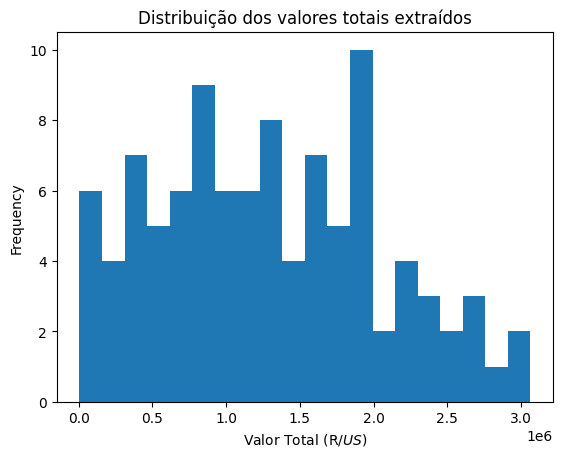

In [9]:
import matplotlib.pyplot as plt

df_faturas['valor_total'].dropna().plot(kind='hist', bins=20, title='Distribuição dos valores totais extraídos')
plt.xlabel('Valor Total (R$ / US$)')
plt.show()


## 7. Conclusões

Das **100 faturas em PDF** processadas, foi possível extrair o número da fatura, a data de emissão e o valor total em **100% dos casos** (100 de 100), depois de ajustar as expressões regulares ao layout real usado pelo emissor das faturas (número no formato `Invoice no: XXXXXXXX`, data em `DD/MM/AAAA` na linha seguinte ao rótulo "Date of issue", e o valor total como o último valor monetário do bloco "Total" ao final do documento, em Rúpias Indianas/INR).

O `tabula-py` também conseguiu extrair automaticamente as **tabelas de itens** de cada fatura (lista de produtos, quantidade, preço unitário e valor bruto), o que possibilitaria, em uma etapa seguinte, montar não só um resumo por fatura, mas também uma tabela detalhada item a item de tudo o que foi comprado/vendido em cada nota.

**Principal aprendizado técnico:** o primeiro conjunto de expressões regulares, pensado de forma genérica, teve **0% de sucesso** na extração do valor total — o formato real das faturas ("Total" seguido de três valores em linhas separadas, com vírgula como separador de milhar) era diferente do que havia sido assumido inicialmente. Isso reforça um ponto importante dessa técnica: **é preciso sempre inspecionar uma amostra real do documento antes de generalizar o padrão de extração** — um regex "genérico demais" tende a falhar silenciosamente (retornando `None` em vez de erro), então validar a taxa de sucesso ao final do processo (como feito aqui) é essencial para saber se a extração realmente funcionou.

**Aplicação prática:** com as 100 faturas convertidas em uma tabela estruturada, seria possível, por exemplo, cruzar esses dados com o financeiro da empresa para conferir se todos os valores recebidos batem com o que foi faturado — um trabalho que, manualmente, levaria horas, e que aqui foi automatizado em segundos.
